ASSIGNMENT 5

Exploring the Latent Space of a Pretrained StyleGAN2 Model Objective

In [13]:
!git clone -q https://github.com/NVlabs/stylegan2-ada-pytorch.git
%cd stylegan2-ada-pytorch
!pip install -q ninja imageio

/content/stylegan2-ada-pytorch/stylegan2-ada-pytorch


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import dnnlib
import legacy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/ffhq.pkl"

with dnnlib.util.open_url(url) as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

G.eval()

print("Model loaded!")

Model loaded!


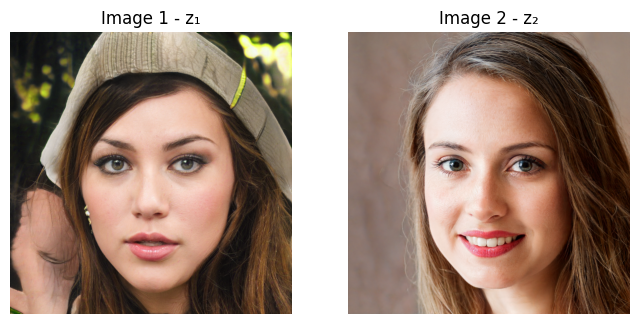

In [15]:
z1 = torch.randn(1, 512).to(device)
z2 = torch.randn(1, 512).to(device)

def generate(z):
    with torch.no_grad():
        image = G(z, None, truncation_psi=0.7, noise_mode="const")

    image = (image * 127.5 + 128).clamp(0, 255)
    image = image[0].permute(1, 2, 0).cpu().numpy().astype(np.uint8)

    return image

img1 = generate(z1)
img2 = generate(z2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Image 1 - z₁")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Image 2 - z₂")
plt.axis("off")

plt.show()

In [16]:
images = []

for t in np.linspace(0, 1, 12):
    z = (1-t) * z1 + t * z2
    images.append(generate(z))

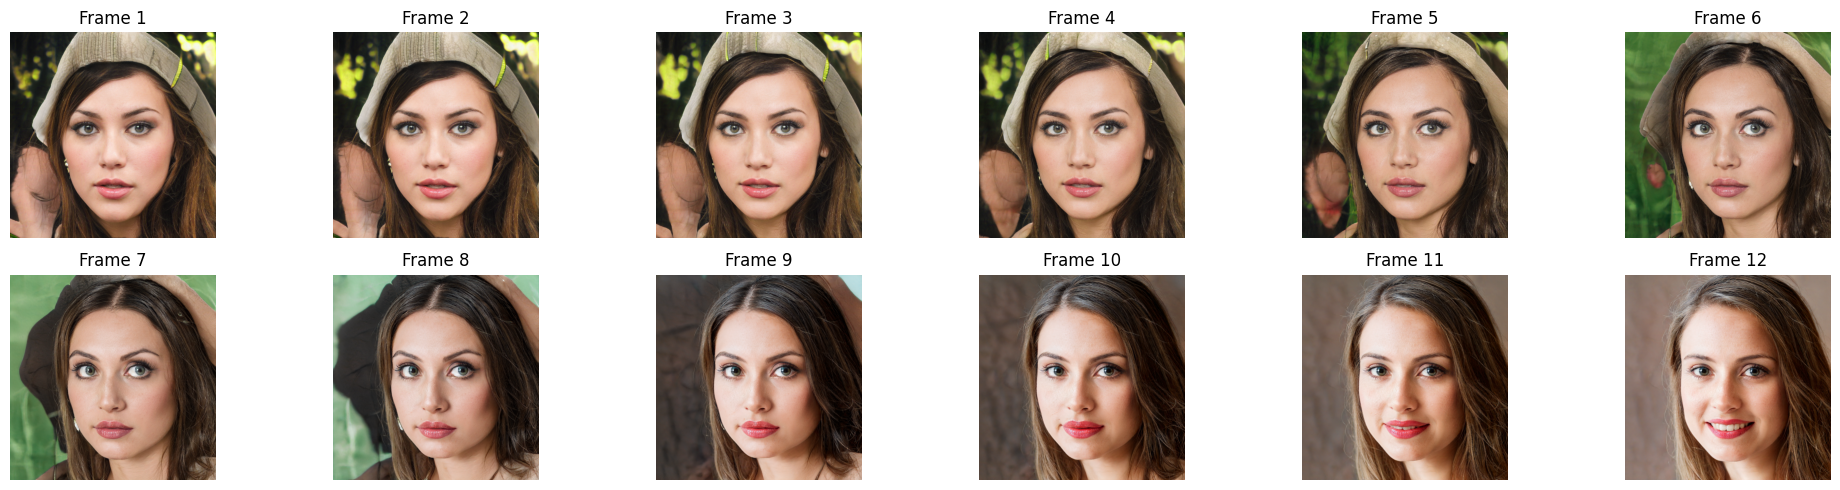

In [17]:
plt.figure(figsize=(20, 5))

for i, image in enumerate(images):
    plt.subplot(2, 6, i+1)
    plt.imshow(image)
    plt.title(f"Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import imageio

imageio.mimsave(
    "/content/stylegan2_interpolation.gif",
    images,
    duration=0.2,
    loop=0
)

print("GIF created!")

GIF created!


In [19]:
modified_images = []

for change in [-2, -1, 0, 1, 2]:

    z = z1.clone()

    # Change only dimension 0 and 1
    z[0, 0] += change
    z[0, 1] += change

    modified_images.append(generate(z))

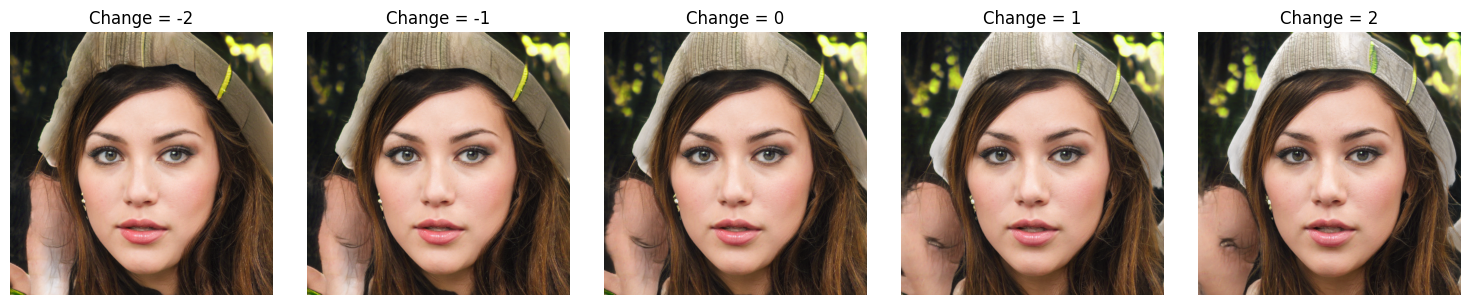

In [20]:
plt.figure(figsize=(15, 3))

for i, image in enumerate(modified_images):

    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(f"Change = {[-2,-1,0,1,2][i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

OBSERVATION


During interpolation, the generated image changes smoothly from the first image to the second, with visual features gradually changing. The latent space represents meaningful visual variations in the generated images. Changing one or two latent dimensions can also affect visible characteristics of the image.